<h2>OUTLINE</h2>
<ol>
    <li><a href="#link_01">Libraries to import</a>
    <li><a href="#link_02">EDA (Exploratory Data Analysis) and Cleaning</a>
    <li><a href="#link_03">Feature Engineering: RFM Metrics (Recency, Frequency and Monetary)</a>
    <li><a href="#link_04">Logarithmic Transformation and Scaler to RFM</a>
    <li><a href="#link_05">Cluster Profile</a>
    <li><a href="#link_06">PCA (PC1 & PC2)</a>
    <li><a href="#link_07">Saving the Scaler and the Model with 'joblib'</a>
    <li><a href="#link_08">Put into Production</a>
</ol>

<h3><a id="link_01">Libraries to import</a></h3>

In [27]:
from sklearn.cluster            import KMeans
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import silhouette_score
from sklearn.decomposition      import PCA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import datetime as dt

<h3><a id="link_02">EDA (Exploratory Data Analysis) and Cleaning</a></H3>

In [28]:
""" dataset & report """

file = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\raw\Online Retail.xlsx"
df_raw = pd.read_excel(file)

N_rows, N_cols = df_raw.shape
print(f"Number of rows: {N_rows:,} | Number of Columns: {N_cols:,}\n")
report = []
for col in df_raw.columns:
    report.append({
        "Col":      col,
        "len":      df_raw[col].count(),
        "dtype":    df_raw[col].dtypes,
        "NaN":      df_raw[col].isnull().sum(),
        "0":        df_raw[col].eq(0).sum(),
        "'0'":      df_raw[col].eq("0").sum(),
        "Unique":   df_raw[col].unique()[0:7].tolist(),
        "N_Unique": df_raw[col].nunique()
    })
df_report = pd.DataFrame(report)
pd.set_option("display.max_colwidth", None)
df_report

Number of rows: 541,909 | Number of Columns: 8



,Col,len,dtype,NaN,0,'0',Unique,N_Unique
0,InvoiceNo,541909,object,0,0,0,"[536365, 536366, 536367, 536368, 536369, 536370, 536371]",25900
1,StockCode,541909,object,0,0,0,"[85123A, 71053, 84406B, 84029G, 84029E, 22752, 21730]",4070
2,Description,540455,object,1454,0,0,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE METAL LANTERN, CREAM CUPID HEARTS COAT HANGER, KNITTED UNION FLAG HOT WATER BOTTLE, RED WOOLLY HOTTIE WHITE HEART., SET 7 BABUSHKA NESTING BOXES, GLASS STAR FROSTED T-LIGHT HOLDER]",4223
3,Quantity,541909,int64,0,0,0,"[6, 8, 2, 32, 3, 4, 24]",722
4,InvoiceDate,541909,datetime64[ns],0,0,0,"[2010-12-01 08:26:00, 2010-12-01 08:28:00, 2010-12-01 08:34:00, 2010-12-01 08:35:00, 2010-12-01 08:45:00, 2010-12-01 09:00:00, 2010-12-01 09:01:00]",23260
5,UnitPrice,541909,float64,0,2515,0,"[2.55, 3.39, 2.75, 7.65, 4.25, 1.85, 1.69]",1630
6,CustomerID,406829,float64,135080,0,0,"[17850.0, 13047.0, 12583.0, 13748.0, 15100.0, 15291.0, 14688.0]",4372
7,Country,541909,object,0,0,0,"[United Kingdom, France, Australia, Netherlands, Germany, Norway, EIRE]",38


In [29]:
""" New features to clean the dataset """

df_raw["CustomerID"] = df_raw["CustomerID"].replace(np.nan, 99999.0)
df_raw["Return"] = np.where(df_raw["Quantity"]<0, 1, 0)
df_raw["Customer_Type"] = np.where(df_raw["CustomerID"]==99999.0, "Customer_Final", "Customer_ID")
df_raw["Description_Error"] = np.where(df_raw["Description"].isnull(), 1, 0)
df_raw["Gift"] = np.where(df_raw["UnitPrice"].eq(0), 1, 0)
df_raw["Total_Invoice"] = df_raw["Quantity"] * df_raw["UnitPrice"]

In [30]:
df_raw[df_raw["UnitPrice"].eq(0) & df_raw["Description"].isnull()].shape

(1454, 13)

In [31]:
df_raw[df_raw["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Return,Customer_Type,Description_Error,Gift,Total_Invoice
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,99999.0,United Kingdom,0,Customer_Final,0,0,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,99999.0,United Kingdom,0,Customer_Final,0,0,-11062.06


In [32]:
""" Copy and Clean """

df_clean = df_raw.copy()
df_clean = df_clean.drop(df_clean[df_clean["Customer_Type"].eq("Customer_Final")].index)
df_clean = df_clean.drop(df_clean[df_clean["Return"].eq(1)].index)
df_clean = df_clean.drop(df_clean[df_clean["Gift"].eq(1)].index)
df_clean = df_clean.drop(columns=["Return", "Customer_Type", "Description_Error", "Gift"])

In [33]:
""" Outliers """
df_clean[["Quantity", "UnitPrice", "Total_Invoice"]].describe(include="all")

,Quantity,UnitPrice,Total_Invoice
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [34]:
q_limit = df_clean["Quantity"].quantile(0.999)
m_limit = df_clean["Total_Invoice"].quantile(0.999)

df_final = df_clean[(df_clean["Quantity"]<=q_limit) & (df_clean["Total_Invoice"]<=m_limit)]

print(f"N_rows of df_raw:   {len(df_raw):,}")
print(f"N_rows of df_clean: {len(df_clean):,}")
print(f"N_rows of df_final: {len(df_final):,}")
print(f"Total drop rows:    {len(df_raw) - len(df_final):,}")

N_rows of df_raw:   541,909
N_rows of df_clean: 397,884
N_rows of df_final: 397,236
Total drop rows:    144,673


<h3><a id="link_03">Feature Engineering: RFM Metrics (Recency, Frequency and Monetary)</a></h3>

In [35]:
""" RFM columns """
snapshot_date = df_final["InvoiceDate"].max() + dt.timedelta(days=1)
rfm = df_final.groupby("CustomerID").agg({
    "InvoiceDate":      lambda x: (snapshot_date - x.max()).days,   # Recency: days without buying
    "InvoiceNo":        "nunique",  # Frequency: Number of unique transactions
    "Total_Invoice":    "sum"   # Monetary: Total money spend
}).reset_index()

rfm.rename(columns={
    "InvoiceDate":      "Recency",
    "InvoiceNo":        "Frequency",
    "Total_Invoice":    "Monetary"
}, inplace=True)

""" RFM Scores and Output """
rfm["R_scores"] = pd.qcut(x=rfm["Recency"], q=4, labels=[4,3,2,1])
rfm["F_scores"] = pd.qcut(x=rfm["Frequency"].rank(method="first"), q=4, labels=[1,2,3,4])
rfm["M_scores"] = pd.qcut(x=rfm["Monetary"], q=4, labels=[1,2,3,4])

rfm["RFM_score"] = (rfm["R_scores"].astype(str) + rfm["F_scores"].astype(str) + rfm["M_scores"].astype(str))
rfm["RFM_Output"] = rfm[["R_scores", "F_scores", "M_scores"]].astype(int).sum(axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_scores,F_scores,M_scores,RFM_score,RFM_Output
0,12347.0,2,7,4310.00,4,4,4,444,12
1,12348.0,75,4,1797.24,2,3,4,234,9
2,12349.0,19,1,1757.55,3,1,4,314,8
3,12350.0,310,1,334.40,1,1,2,112,4
4,12352.0,36,8,2506.04,3,4,4,344,11


<h3><a id="link_04">Logarithmic Transformation and Scaler to RFM</a></h2>

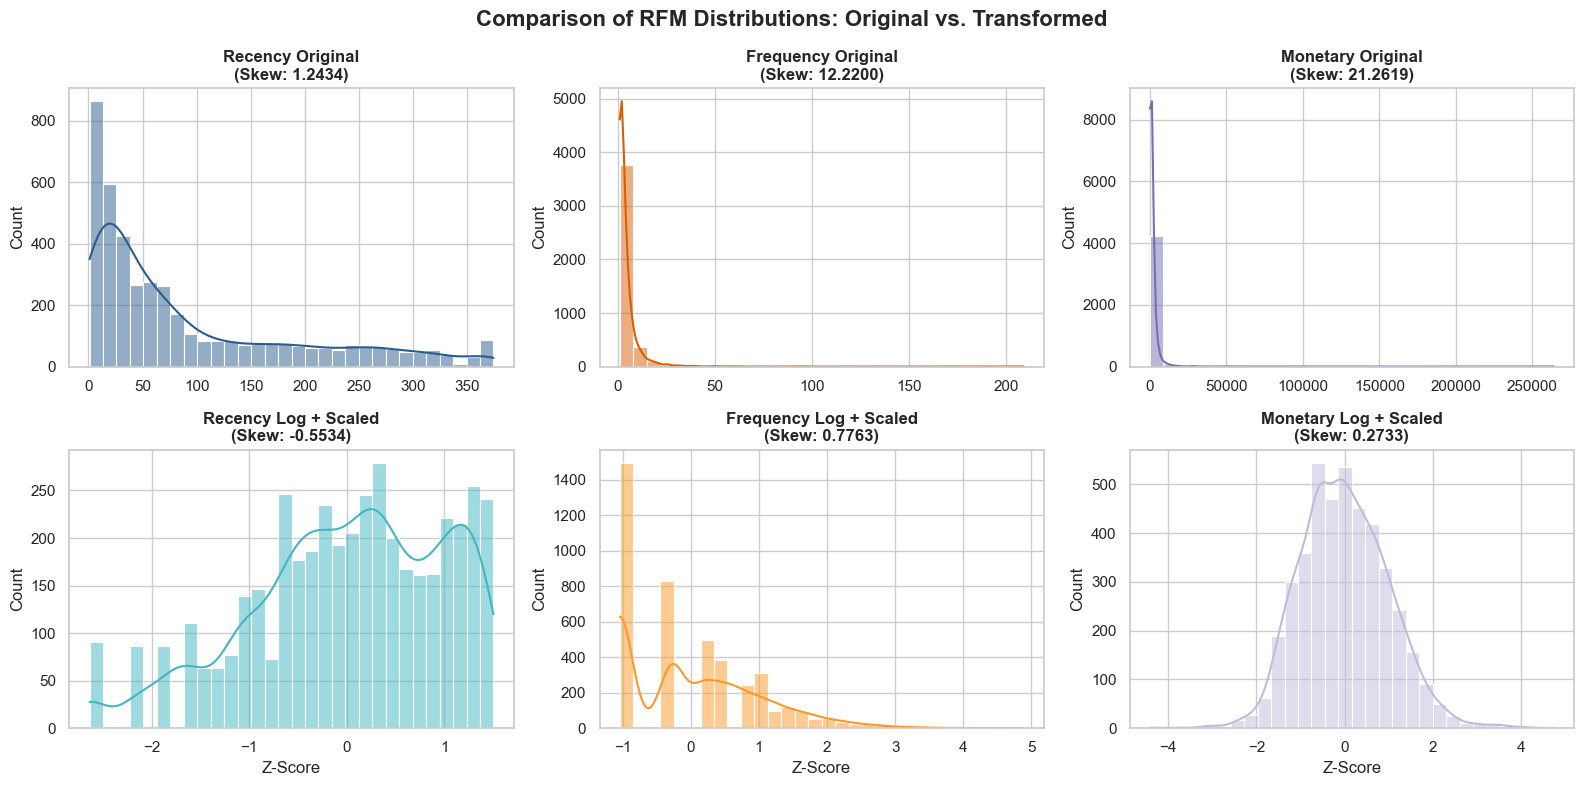

In [ ]:
""" Style of the graph """

plt.rcParams["font.family"] = "sans-serif"

""" Logarithmic transformation """
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log1p)

""" Scaler """
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_log), columns=["Recency", "Frequency", "Monetary"])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,8))
features = ["Recency", "Frequency", "Monetary"]
colors_without = ["#2b5c8f", "#d95f02", "#7570b3"]
colors_with = ["#41b6c4", "#fe9929", "#bcbddc"]

""" Distribution graphic without log and scaler """
for i, col in enumerate(features):
    sns.set_theme(style="whitegrid")
    sns.histplot(data=rfm[col], kde=True, ax=axes[0,i], color=colors_without[i], bins=30)
    skewness = rfm[col].skew()
    axes[0,i].set_title(f"{col} Original\n(Skew: {skewness:,.4f})", fontsize=12, fontweight="bold")
    axes[0,i].set_xlabel("")

""" Distribution graphic with log and scaler """
for i, col in enumerate(features):
    sns.set_theme(style="whitegrid")
    sns.histplot(data=rfm_scaled[col], kde=True, ax=axes[1,i], color=colors_with[i], bins=30)
    skewness_scaled = rfm_scaled[col].skew()
    axes[1,i].set_title(f"{col} Log + Scaled\n(Skew: {skewness_scaled:,.4f})", fontsize=12, fontweight="bold")
    axes[1,i].set_xlabel("Z-Score")

plt.suptitle("Comparison of RFM Distributions: Original vs. Transformed", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [37]:
rfm_scaled["CustomerID"] = rfm["CustomerID"]
rfm_scaled.head()

,Recency,Frequency,Monetary,CustomerID
0,-2.151398,1.114705,1.443921,12347.0
1,0.382784,0.493068,0.742149,12348.0
2,-0.577269,-1.046865,0.724232,12349.0
3,1.375024,-1.046865,-0.607078,12350.0
4,-0.130416,1.263035,1.008879,12352.0


<h3><a id="link_05">Cluster Profile</a></h3>

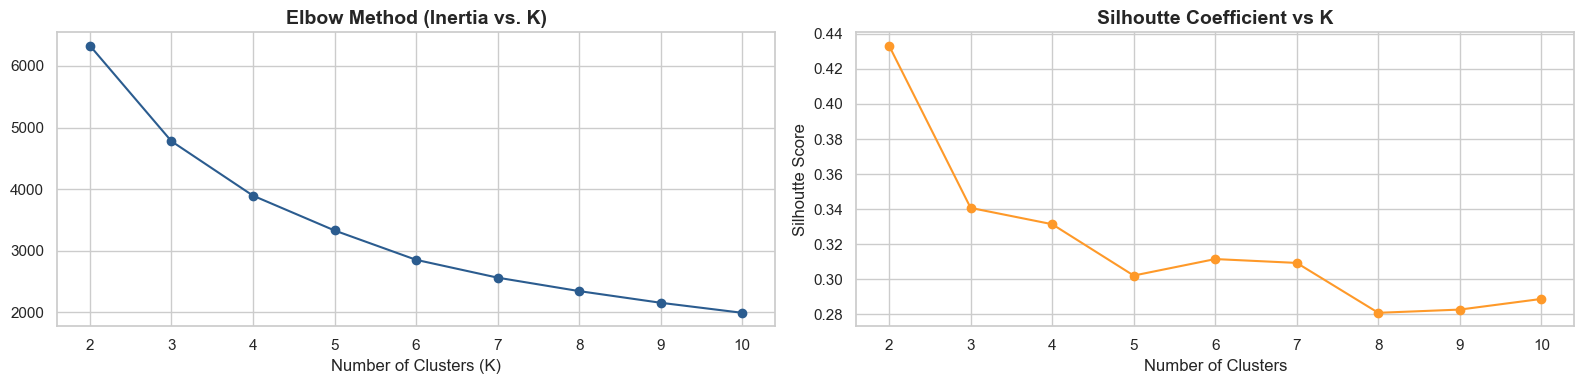

In [38]:
""" Search the K value to Cluster (k_optimal) """

X = rfm_scaled.drop(columns=["CustomerID"])

sse = {}                # Sum of Squared Errors (.inertia_)
silh_coef = {}          # Slihouette Coefficient
k_range = range(2,11)   # k=2 to 10

for k in k_range:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sse[k] = k_means.inertia_
    silh_score = silhouette_score(X=X, labels=k_means.labels_)
    silh_coef[k] = silh_score

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16,4))

# Elbow Method
ax1.plot(list(sse.keys()), list(sse.values()), marker="o", color="#2b5c8f")
ax1.set_title("Elbow Method (Inertia vs. K)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("")


# Silhoutte Coefficient Method
ax2.plot(list(silh_coef.keys()), list(silh_coef.values()), marker="o", color="#fe9929")
ax2.set_title("Silhoutte Coefficient vs K", fontsize=14, fontweight="bold")
ax2.set_xlabel("Number of Clusters")
ax2.set_ylabel("Silhoutte Score")

plt.tight_layout()
plt.show()

In [39]:
""" Create the Cluster Profile (Code) """

k_optimal = 4
k_means = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm_scaled["Cluster"] = k_means.fit_predict(X)
rfm["Cluster"] = rfm_scaled["Cluster"]

cluster_profile = rfm.groupby("Cluster").agg({
    "Recency":      "mean",
    "Frequency":    "mean",
    "Monetary":     ["mean", "count"]
}).round(2)

cluster_profile.columns = [
    "Mean_Recency (Days)",
    "Mean_Frequency (Purchase)",
    "Mean_Amount ($ USD)",
    "Quantity (Clients)"
]

cluster_profile["Clients_Percentage"] = ((cluster_profile["Quantity (Clients)"] / len(rfm))*100).round(2)
print("Cluster Profiling (Average Metrics)")
cluster_profile

Cluster Profiling (Average Metrics)


,Mean_Recency (Days),Mean_Frequency (Purchase),Mean_Amount ($ USD),Quantity (Clients),Clients_Percentage
Cluster,,,,,
0,70.37,4.15,1574.67,1275,29.49
1,21.87,1.83,457.72,794,18.36
2,189.92,1.27,338.04,1504,34.78
3,10.30,12.97,6644.04,751,17.37


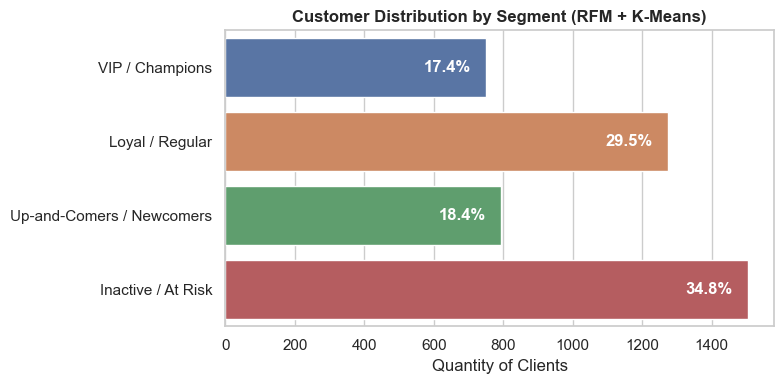

In [42]:
""" Cluster Profile Assignment """

cluster_names = {
    0: "Loyal / Regular",
    1: "Up-and-Comers / Newcomers",
    2: "Inactive / At Risk",
    3: "VIP / Champions"
}

rfm["Cluster_Name"] = rfm["Cluster"].map(cluster_names)

segment_order = [
    "VIP / Champions",
    "Loyal / Regular",
    "Up-and-Comers / Newcomers",
    "Inactive / At Risk"
]

""" Profile Distribution View (Customers by Segment) """
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
axes = sns.countplot(
    data=rfm,
    y="Cluster_Name",
    order=segment_order,
    hue="Cluster_Name"
)

axes.set_title("Customer Distribution by Segment (RFM + K-Means)", fontsize=12, fontweight="bold")
axes.set_xlabel("Quantity of Clients")
axes.set_ylabel("")

# Agregar Porcentajes en las barras
total = len(rfm)
for p in axes.patches:
    percentage = f"{100 * p.get_width() / total:.1f}%"
    x = p.get_width() - 180
    y = p.get_y() + p.get_height() / 2
    axes.annotate(percentage, (x,y), va="center", fontsize=12, fontweight="bold", color="#ffffff")

plt.tight_layout()
plt.show()

<h3><a id="link_06">PCA (PC1 & PC2)</a></h3>

Variance explained by PC1:      75.58%
Variance explained by PC2:      18.60%
Total variance explained (2D):  94.17%


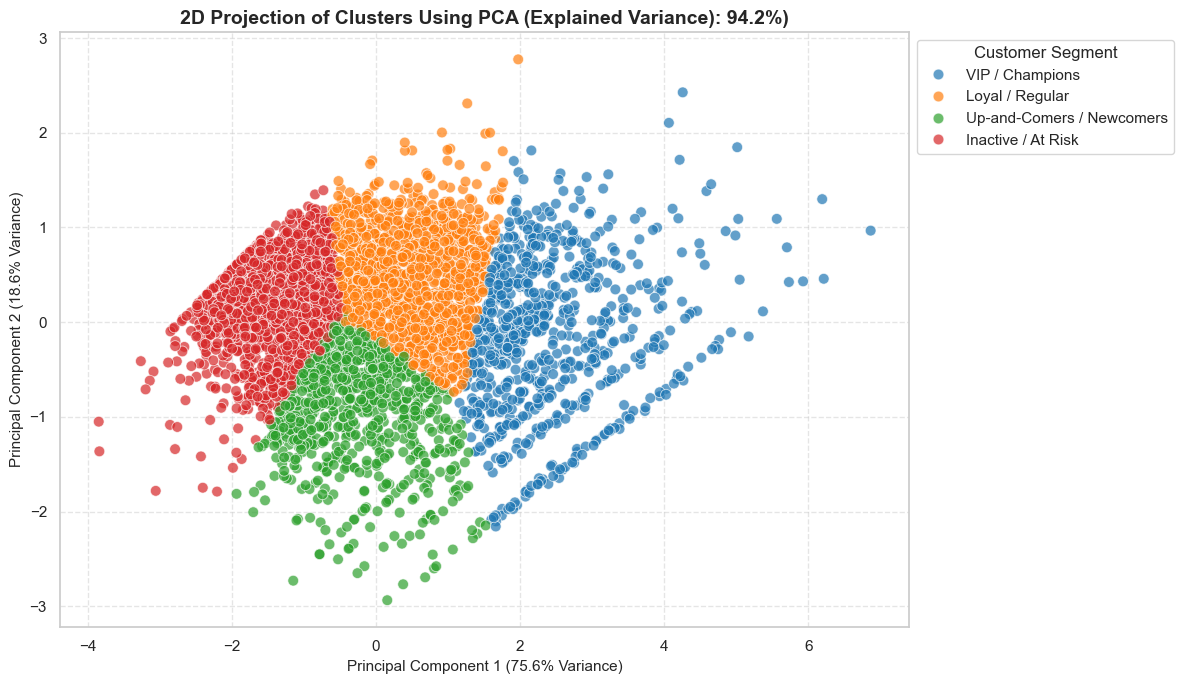

In [46]:
# 1. Select only scaled numeric variables (without labels or IDs)
X = rfm_scaled[['Recency', 'Frequency', 'Monetary']]

# 2. Initialize and train PCA to reduce the data to 2 components
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X)

# 3. Create a DataFrame with the principal components
rfm_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
rfm_pca['Cluster_Name'] = rfm['Cluster_Name']
rfm_pca['Cluster'] = rfm['Cluster']

# 4. Calculate the variance explained by the two components
var_explained = pca.explained_variance_ratio_
total_var = var_explained.sum() * 100

print(f"Variance explained by PC1:      {var_explained[0]*100:.2f}%")
print(f"Variance explained by PC2:      {var_explained[1]*100:.2f}%")
print(f"Total variance explained (2D):  {total_var:.2f}%")

# 5. Plotting the Clusters in 2D PCA Space
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=rfm_pca,
    x='PC1',
    y='PC2',
    hue='Cluster_Name',
    hue_order=segment_order,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    alpha=0.7,
    s=60
)

plt.title(f'2D Projection of Clusters Using PCA (Explained Variance): {total_var:.1f}%)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}% Variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}% Variance)', fontsize=11)
plt.legend(title='Customer Segment', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h3><a id="link_07">Saving the Scaler and the Model with 'joblib'</a></h3>

In [48]:
import os
import joblib

print("Your actual folder is:", os.getcwd())
# 1. Create the 'models' directory(folder) if it does not exist
os.makedirs("models", exist_ok=True)

# 2. Save the StandardScaler object that you already have in memory
scaler_path = "models/scaler_rfm.joblib"
joblib.dump(scaler, scaler_path)
print(f"✅ StandardScaler guardado en: {scaler_path}")

# 3. Save the trained K-Means model that you already have in memory
k_means_path = "models/kmeans_rfm.joblib"
joblib.dump(k_means, k_means_path)
print(f"✅ Modelo K-Means guardado en: {k_means_path}")

Your actual folder is: c:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\notebooks
✅ StandardScaler guardado en: models/scaler_rfm.joblib
✅ Modelo K-Means guardado en: models/kmeans_rfm.joblib


<h3><a id="link_08">Put into Poduction</a></h3>

In [54]:
# Example of usage in an inference/production environment:
import joblib
import numpy as np

# 1. Load Saved Objects
loaded_scaler = joblib.load("models/scaler_rfm.joblib")
loaded_kmeans = joblib.load("models/kmeans_rfm.joblib")

# 2. Mapping Dictionary for Business Segments
cluster_names = {
    0: "Loyal / Regular",
    1: "Up-and-Comers / Newcomers",
    2: "Inactive / At Risk",
    3: "VIP / Champions"
}

# 3. Let's assume a new customer with: Recency=12 days, Frequency=5 purchases, Monetary=$1,200
new_client_raw = pd.DataFrame([[12, 5, 1200]], columns=["Recency", "Frequency", "Monetary"])

# 4. Apply the logarithm
new_client_log = np.log1p(new_client_raw)

# 5. Transform using the saved Scaler
scaled_array = loaded_scaler.transform(new_client_log)
new_client_scaled = pd.DataFrame(scaled_array, columns=new_client_log.columns)

# 6. Predict the Cluster
assigned_cluster_id = loaded_kmeans.predict(new_client_scaled)[0]

# 7. Map the ID to the human-readable name of the segment
assigned_cluster_name = cluster_names.get(assigned_cluster_id, "Unknown")

print(f"The Client belong to the Cluster: {assigned_cluster_name}")

The Client belong to the Cluster: Loyal / Regular
